In [2]:
#give me sample data for decision tree, such as the likely hood of someone leaving their gym membership

dataset = [
    [2.8, 1.8, 0],
    [1.5, 2.3, 0],
    [3.4, 1.0, 0],
    [2.0, 3.6, 1],
    [3.1, 3.9, 1],
    [1.3, 3.3, 1],
    [7.6, 2.8, 1],
    [8.9, 1.2, 1],
    [7.4, 3.6, 1],
    [9.2, 0.9, 1],
]



## The dataset in real life: a hiring decision

To
make
the
numbers
mean
something, imagine
each
row is a ** job
candidate **, and we
want
to
predict
whether
they
get ** hired **.

Each
row is `[X1, X2,


class ]`:

    |


Column | Real - life
meaning | Range |
| -------- | ------------------- | ------- |
| `X1` | ** Years
of
relevant
experience ** | 0 – 10 |
                    | `X2` | ** Interview
score ** (panel rating) | 0 – 4 |
                              | `


class ` | ** Outcome **: `0` = not hired, `1` = hired | 0 or 1 |


So
a
row
like
`[7.6, 2.8, 1]`
means: *a
candidate
with 7.6 years of experience and an interview score of 2.8, who was hired.*

** What
the
tree
discovers
on
its
own: ** after
training, the
decision
boundary
turns
out
to
be

> ** Hire if the
interview
score is strong(X2 ≥ 2.8), OR if experience is very high (X1 ≥ 8.9).**

This
matches
how
real
hiring
often
works: a
great
interview
earns
an
offer
regardless
of
experience, and a
very
experienced
candidate
can
still
get
through
on
experience
even
after
a
middling
interview.The
tree
wasn
't *told* this rule — it found it by minimising Gini impurity, one split at a time.

** Why
this
dataset
needs
two
questions. ** No
single
line
separates
the
hired
from the

not -hired: strong - interview
candidates
are
hired
whether
junior or senior, so
the
tree
must
ask
about
the
interview
score * first *, then
ask
about
experience
only
for the weaker - interview group.That two-question structure is exactly what you will see printed below when the tree is built.


In [5]:
import pandas as pd
df = pd.DataFrame(dataset, columns=['years_experience', 'interview_score', 'hired'])

In [6]:
df

,years_experience,interview_score,hired
0,2.8,1.8,0
1,1.5,2.3,0
2,3.4,1.0,0
3,2.0,3.6,1
4,3.1,3.9,1
5,1.3,3.3,1
6,7.6,2.8,1
7,8.9,1.2,1
8,7.4,3.6,1
9,9.2,0.9,1


In [7]:
print(df.isnull().sum())

years_experience    0
interview_score     0
hired               0
dtype: int64


In [8]:
# Compute correlation matrix

corr_matrix = df.corr()

In [9]:
corr_matrix

,years_experience,interview_score,hired
years_experience,1.000000,-0.387209,0.468503
interview_score,-0.387209,1.000000,0.440331
hired,0.468503,0.440331,1.000000


In [10]:
target = 'years_experience' # replace with your target column

In [11]:
correlations = corr_matrix[target].abs().sort_values(ascending=False)
correlations

years_experience    1.000000
hired               0.468503
interview_score     0.387209
Name: years_experience, dtype: float64

In [15]:
selected_features = correlations.index[1:6]  # top 5 correlated features, for example
selected_features
target = 'hired'

In [16]:
df

,years_experience,interview_score,hired
0,2.8,1.8,0
1,1.5,2.3,0
2,3.4,1.0,0
3,2.0,3.6,1
4,3.1,3.9,1
5,1.3,3.3,1
6,7.6,2.8,1
7,8.9,1.2,1
8,7.4,3.6,1
9,9.2,0.9,1


In [17]:
X = df[selected_features]

y = df[target]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
X_test

,hired,interview_score
8,1,3.6
1,0,2.3
5,1,3.3


In [21]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(criterion='gini', random_state=42)

clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict on test set

y_pred = clf.predict(X_test)

# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Classification report for detailed metrics

print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[1 0]
 [0 2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



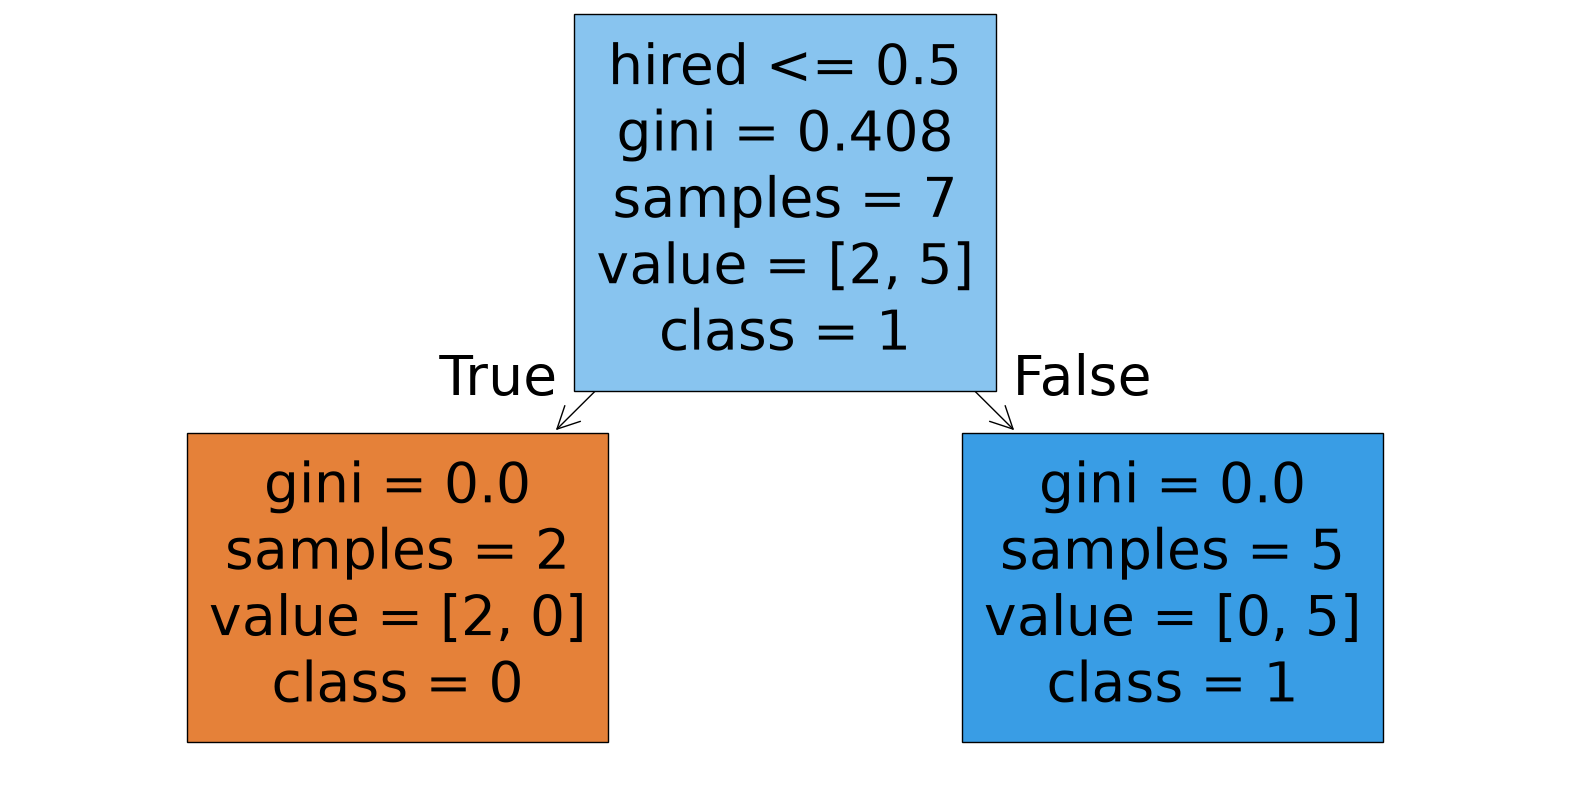

In [25]:
from sklearn import tree

import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

tree.plot_tree(clf, feature_names=selected_features, class_names=clf.classes_.astype(str), filled=True)

plt.show()